# Price Forecasting - Prophet Model

This notebook builds a reusable forecasting function using Facebook Prophet to predict future closing prices for any of the 5 tickers. The model is evaluated on a held-out test period before being reused in the Streamlit app.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

df = pd.read_csv("../data/stock_data.csv", parse_dates=["Date"])
df["Date"] = pd.to_datetime(df["Date"], utc=True).dt.tz_localize(None)
df = df.dropna().reset_index(drop=True)
df.head()

,Date,Ticker,Open,High,Low,Close,Volume
0,2024-09-10 04:00:00,AAPL,217.103866,219.642626,214.932032,218.283997,51591000
1,2024-09-11 04:00:00,AAPL,219.622839,221.239307,216.082448,220.812881,44587100
2,2024-09-12 04:00:00,AAPL,220.654187,221.695479,217.996427,220.921951,37455600
3,2024-09-13 04:00:00,AAPL,221.725217,222.181393,220.069073,220.654175,36766600
4,2024-09-16 04:00:00,AAPL,214.743628,215.417995,212.145368,214.525467,59357400


In [6]:
TICKER = "AAPL"
TEST_DAYS = 30

ticker_df = df[df["Ticker"] == TICKER][["Date", "Close"]].reset_index(drop=True)
ticker_df = ticker_df.rename(columns={"Date": "ds", "Close": "y"})

train = ticker_df.iloc[:-TEST_DAYS]
test = ticker_df.iloc[-TEST_DAYS:]

print(f"Training on {len(train)} days, testing on {len(test)} days")
print(f"Test period: {test['ds'].min().date()} to {test['ds'].max().date()}")

Training on 471 days, testing on 30 days
Test period: 2026-07-29 to 2026-09-09


In [11]:
model = Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=False)
model.fit(train)

18:36:23 - cmdstanpy - INFO - Chain [1] start processing
18:36:23 - cmdstanpy - INFO - Chain [1] done processing


In [20]:
periods_needed = (test["ds"].max() - train["ds"].max()).days

future = model.make_future_dataframe(periods=periods_needed)
forecast = model.predict(future)

forecast_test = forecast[forecast["ds"].isin(test["ds"])][["ds", "yhat", "yhat_lower", "yhat_upper"]]
comparison = test.merge(forecast_test, on="ds")

print(f"Matched {len(comparison)} out of {len(test)} test days")
comparison.head()

Matched 30 out of 30 test days


,ds,y,yhat,yhat_lower,yhat_upper
0,2026-07-29 04:00:00,337.898590,323.669335,312.905895,335.062252
1,2026-07-30 04:00:00,333.142670,324.205446,313.497312,334.684952
2,2026-07-31 04:00:00,308.643829,324.564377,313.209647,335.760664
3,2026-08-03 04:00:00,303.158569,325.277589,313.260350,336.138985
4,2026-08-04 04:00:00,309.113403,326.992579,316.334643,338.710374


In [21]:
mae = mean_absolute_error(comparison["y"], comparison["yhat"])
mape = mean_absolute_percentage_error(comparison["y"], comparison["yhat"]) * 100

print(f"MAE: ${mae:.2f}")
print(f"MAPE: {mape:.2f}%")

MAE: $20.99
MAPE: 6.72%


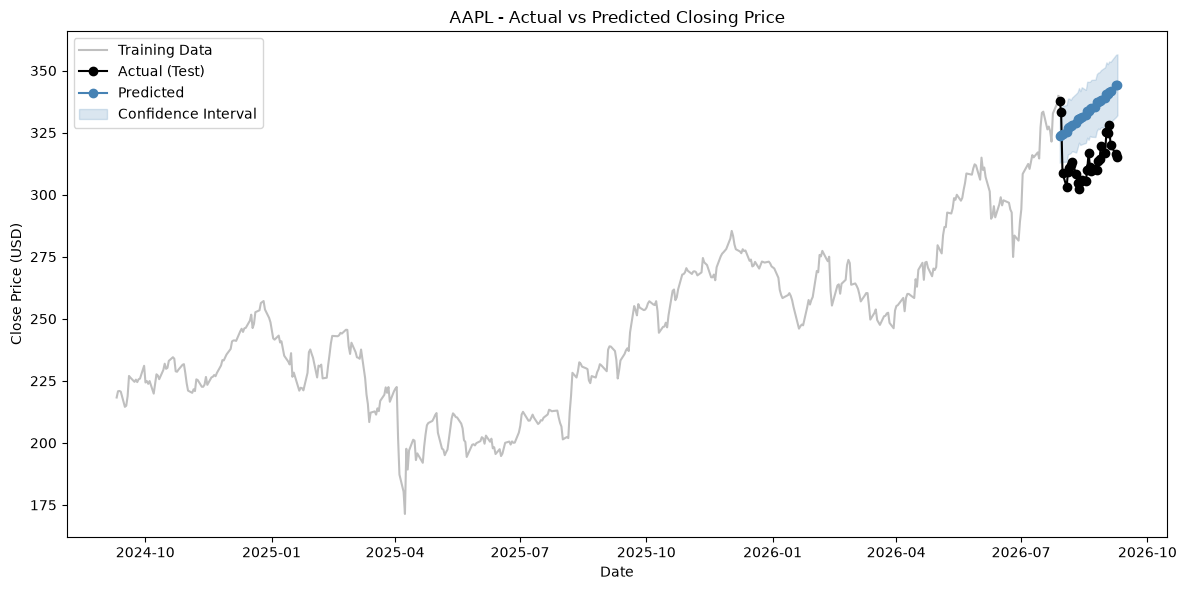

In [22]:
plt.figure(figsize=(12,6))
plt.plot(train["ds"], train["y"], label="Training Data", color="gray", alpha=0.5)
plt.plot(comparison["ds"], comparison["y"], label="Actual (Test)", color="black", marker="o")
plt.plot(comparison["ds"], comparison["yhat"], label="Predicted", color="steelblue", marker="o")
plt.fill_between(comparison["ds"], comparison["yhat_lower"], comparison["yhat_upper"], color="steelblue", alpha=0.2, label="Confidence Interval")

plt.title(f"{TICKER} - Actual vs Predicted Closing Price")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()

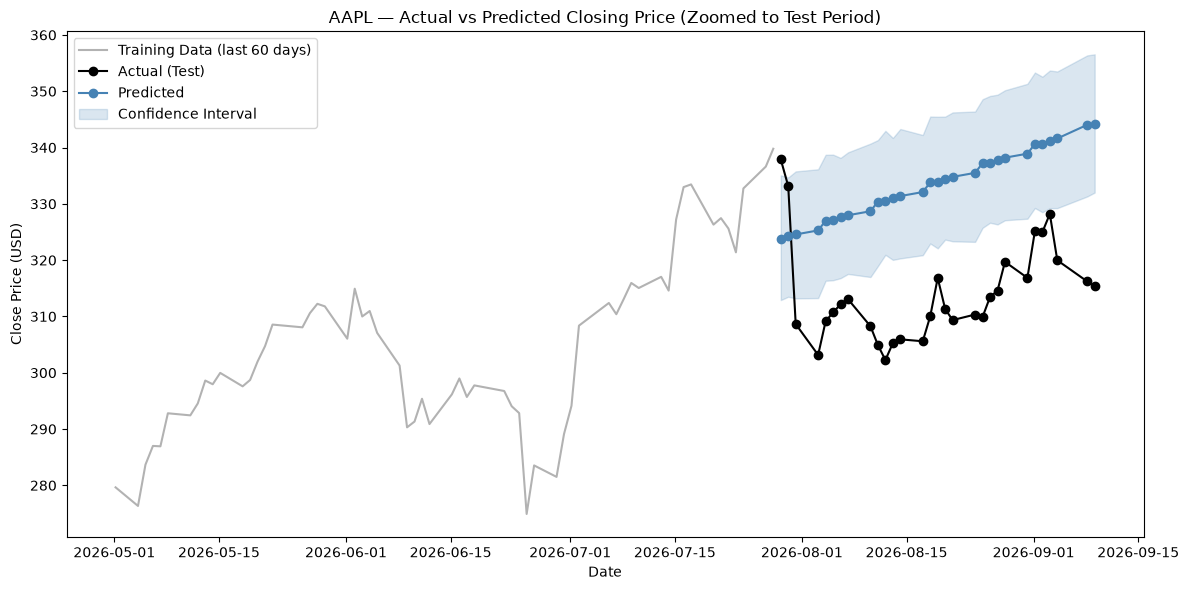

In [23]:
plt.figure(figsize=(12, 6))

recent_train = train.tail(60)
plt.plot(recent_train["ds"], recent_train["y"], label="Training Data (last 60 days)", color="gray", alpha=0.6)
plt.plot(comparison["ds"], comparison["y"], label="Actual (Test)", color="black", marker="o")
plt.plot(comparison["ds"], comparison["yhat"], label="Predicted", color="steelblue", marker="o")
plt.fill_between(comparison["ds"], comparison["yhat_lower"], comparison["yhat_upper"],
                  color="steelblue", alpha=0.2, label="Confidence Interval")

plt.title(f"{TICKER} — Actual vs Predicted Closing Price (Zoomed to Test Period)")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
within_interval = ((comparison["y"] >= comparison["yhat_lower"]) & (comparison["y"] <= comparison["yhat_upper"])).sum()
total = len(comparison)
pct_within = within_interval / total * 100

print(f"{within_interval} out of {total} actual values fell within the confidence interval ({pct_within:.1f}%)")

1 out of 30 actual values fell within the confidence interval (3.3%)


In [25]:
below = (comparison["y"] < comparison["yhat_lower"]).sum()
above = (comparison["y"] > comparison["yhat_upper"]).sum()
within = len(comparison) - below - above

print(f"Below interval: {below}")
print(f"Above interval: {above}")
print(f"Within interval: {within}")

Below interval: 28
Above interval: 1
Within interval: 1


## Model Evaluation Summary

- Trained a Prophet model on AAPL closing prices (471 training days), evaluated against the full 30-day held-out test period.
- Disabling yearly seasonality improved accuracy: MAE dropped from **\$39.08** to **\$20.99**, and MAPE from **12.63%** to **6.72%**. With only 2 years of history, the model could not reliably estimate a yearly cycle, so removing it reduced noise.
- Confidence interval analysis revealed a systematic bias: **28** of **30** actual values (93%) fell below the model's lower confidence bound, with only 1 falling within the interval. This means the model consistently overestimated future prices — it projected AAPL's recent upward trend to continue, but the actual price stalled and pulled back during the test period.
- **Takeaway:** a ~7% average error looks reasonable in isolation, but the confidence interval breakdown exposes a real limitation — Prophet's trend extrapolation assumes recent momentum continues, and does not adapt when that momentum reverses. This is a known weakness of trend-based forecasting for financial data. The model's output should be presented as a directional estimate, not a precise or reliable prediction — an important caveat to communicate honestly when demonstrating the app.